In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

In [2]:
CC = pd.read_csv('datasets//Chicago_Crimes.csv')

In [3]:
CC

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13439321,JH237424,04/14/2024 12:00:00 AM,040XX S PRAIRIE AVE,0890,THEFT,FROM BUILDING,APARTMENT,False,False,...,3,38.0,06,1178707.0,1878256.0,2024,12/21/2024 03:40:46 PM,41.821236,-87.619921,"(41.821236024, -87.619920712)"
1,13437420,JH234779,04/14/2024 12:00:00 AM,023XX W CERMAK RD,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,COMMERCIAL / BUSINESS OFFICE,False,False,...,25,31.0,26,1161210.0,1889347.0,2024,12/21/2024 03:40:46 PM,41.852052,-87.683801,"(41.852051675, -87.683800849)"
2,13428676,JH224478,04/14/2024 12:00:00 AM,043XX W LE MOYNE ST,0917,MOTOR VEHICLE THEFT,"CYCLE, SCOOTER, BIKE WITH VIN",STREET,False,False,...,36,23.0,07,1146960.0,1909501.0,2024,12/21/2024 03:40:46 PM,41.907640,-87.735587,"(41.907640473, -87.735587478)"
3,13429357,JH225293,04/14/2024 12:00:00 AM,039XX W ADAMS ST,143A,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,STREET,True,False,...,28,26.0,15,1150158.0,1898721.0,2024,12/21/2024 03:40:46 PM,41.877997,-87.724121,"(41.877997275, -87.724120826)"
4,13430098,JH226395,04/14/2024 12:00:00 AM,011XX W 112TH PL,0890,THEFT,FROM BUILDING,RESIDENCE,False,False,...,21,75.0,06,1170856.0,1830157.0,2024,12/21/2024 03:40:46 PM,41.689421,-87.650123,"(41.6894214, -87.650123247)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249118,13805239,JJ217509,04/12/2025 12:00:00 AM,029XX W LOGAN BLVD,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,APARTMENT,False,False,...,1,22.0,26,1156478.0,1917149.0,2025,04/19/2025 03:41:24 PM,41.928440,-87.700416,"(41.928439867, -87.700415972)"
249119,13804023,JJ215813,04/12/2025 12:00:00 AM,094XX S HARVARD AVE,0430,BATTERY,AGGRAVATED - OTHER DANGEROUS WEAPON,STREET,False,False,...,9,49.0,04B,1175694.0,1842631.0,2025,04/19/2025 03:41:24 PM,41.723545,-87.632040,"(41.723545182, -87.632039508)"
249120,13803926,JJ215943,04/12/2025 12:00:00 AM,084XX S VINCENNES AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,21,71.0,08B,1173850.0,1848976.0,2025,04/19/2025 03:41:24 PM,41.740998,-87.638606,"(41.74099774, -87.638606337)"
249121,13803475,JJ215338,04/12/2025 12:00:00 AM,050XX S ABERDEEN ST,0530,ASSAULT,AGGRAVATED - OTHER DANGEROUS WEAPON,STREET,True,False,...,20,61.0,04A,1169838.0,1871348.0,2025,04/19/2025 03:41:24 PM,41.802477,-87.652657,"(41.802477219, -87.652657244)"


In [4]:
CC.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location'],
      dtype='object')

<h1> Insight #1 Total Crime Count per Year </h1>
<h3>Show how crimes have evolved over time.</h3>

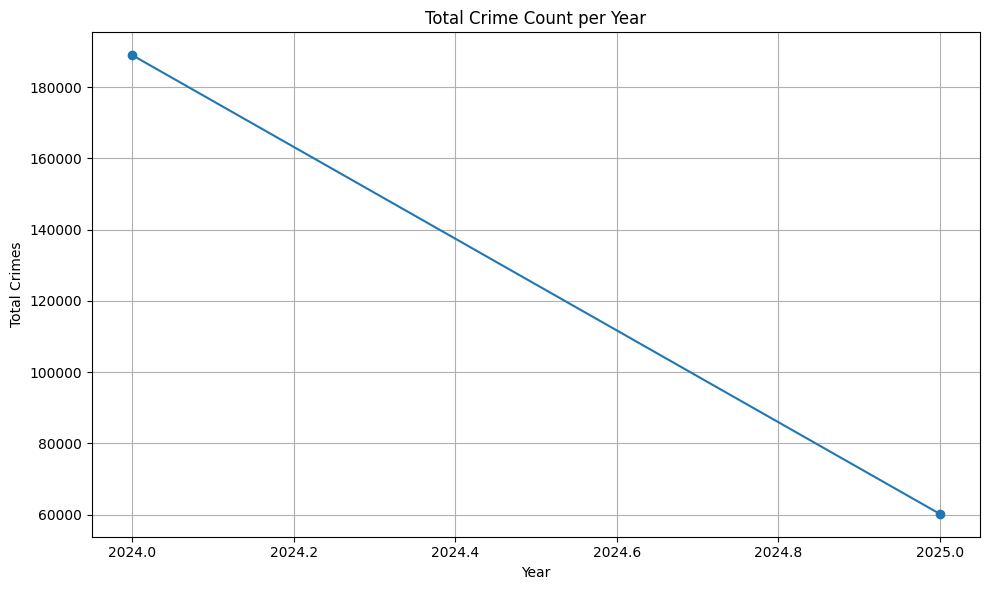

Year
2024    188918
2025     60205
dtype: int64

In [5]:
plt.figure(figsize=(10, 6))
crime_by_year = CC.groupby('Year').size()
crime_by_year.plot(kind='line', marker='o')
plt.title('Total Crime Count per Year')
plt.xlabel('Year')
plt.ylabel('Total Crimes')
plt.grid(True)
plt.tight_layout()
plt.show()
crime_by_year

<h1>Insight # 2 Total Crime Count per Month</h1>
<h3>Show the monthly distribution of crimes for a year.</h3>

C:\Users\JUSTINEENRIQUEZ\AppData\Local\Temp\ipykernel_16904\2116716655.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  CC['Date'] = pd.to_datetime(CC['Date'])  # Convert 'Date' column to datetime format


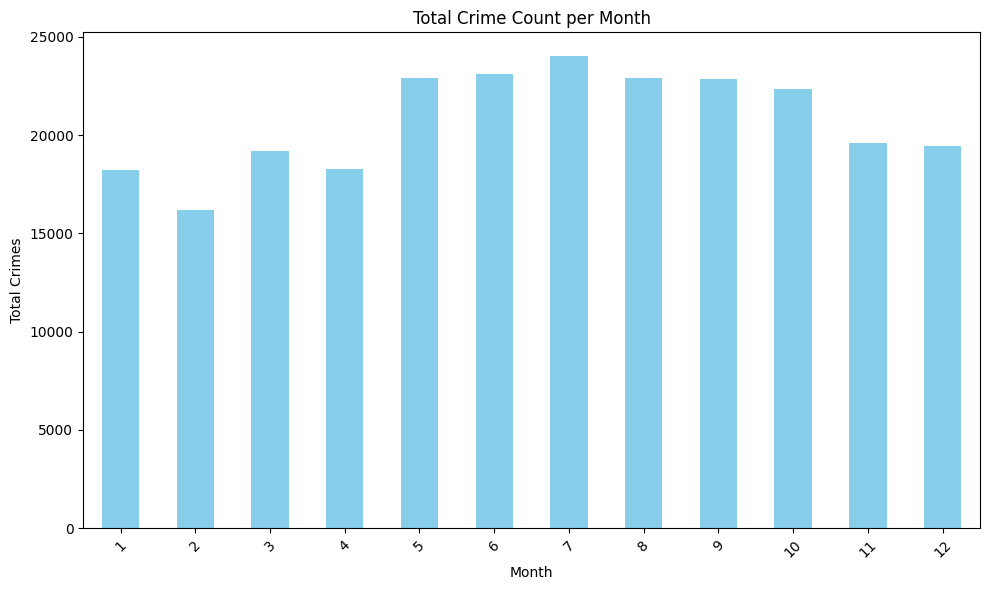

Month
1     18222
2     16217
3     19179
4     18295
5     22932
6     23108
7     24029
8     22884
9     22856
10    22353
11    19610
12    19438
dtype: int64

In [6]:
# Assuming 'CC' is your DataFrame and 'Date' is the column containing date information
CC['Date'] = pd.to_datetime(CC['Date'])  # Convert 'Date' column to datetime format
CC['Month'] = CC['Date'].dt.month  # Extract the month from the 'Date' column

# Grouping by Month and counting the number of crimes
crime_by_month = CC.groupby('Month').size()

# Plotting the result
plt.figure(figsize=(10, 6))
crime_by_month.plot(kind='bar', color='skyblue')
plt.title('Total Crime Count per Month')
plt.xlabel('Month')
plt.ylabel('Total Crimes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
crime_by_month

<h1>Insight # 3 Top 10 Crime Types by Frequency</h1>
<h3>Display the most common types of crimes.</h3>

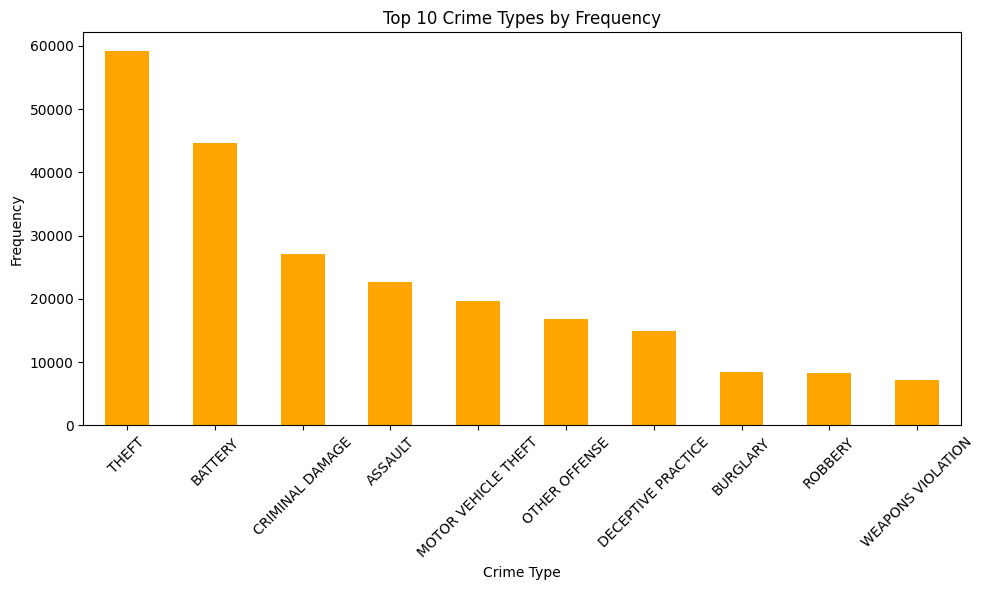

In [7]:
plt.figure(figsize=(10, 6))
crime_types = CC['Primary Type'].value_counts().head(10)
crime_types.plot(kind='bar', color='orange')
plt.title('Top 10 Crime Types by Frequency')
plt.xlabel('Crime Type')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h1>Insight # 4 Crime Type by Location</h1>
<h3>Display crimes by location descriptions (e.g., apartment, street).</h3>

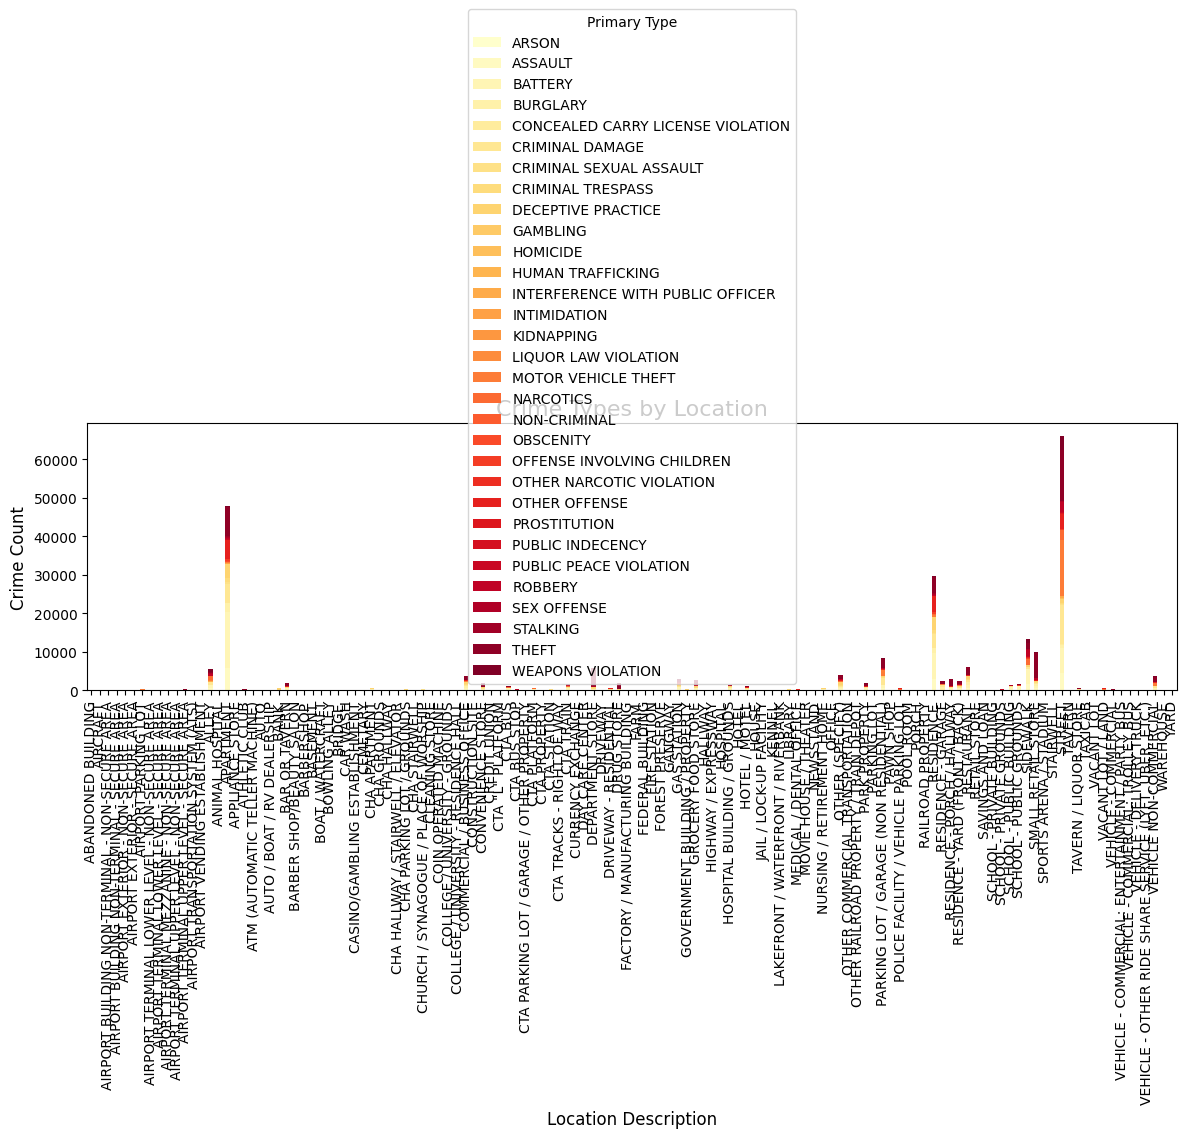

In [8]:
location_crimes = CC.groupby(['Location Description', 'Primary Type']).size().unstack().fillna(0)

# Create a bar chart for each location with the total number of crimes for each crime type
location_crimes.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='YlOrRd')

# Set the title and labels
plt.title('Crime Types by Location', fontsize=16)
plt.xlabel('Location Description', fontsize=12)
plt.ylabel('Crime Count', fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=90)

# Adjust layout for a clean fit
plt.tight_layout()

# Show the plot
plt.show()

<h1>Insight #5 Arrested vs Not Arrested Crimes</h1>
<h3>Display the percentage of crimes that involved arrests.</h3>

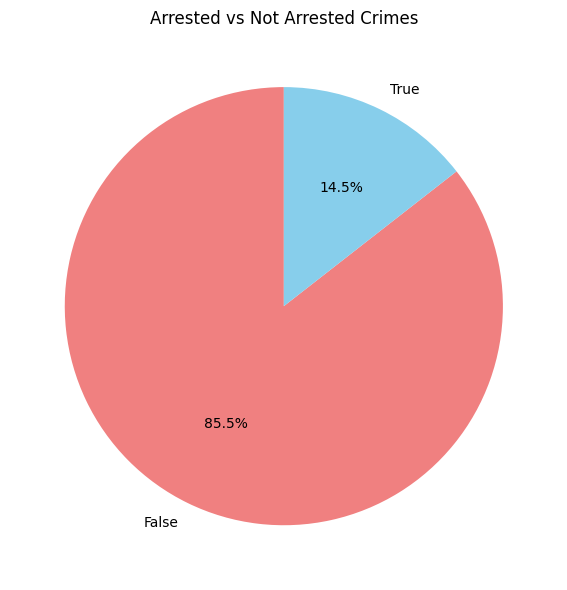

In [9]:
plt.figure(figsize=(6, 6))
arrest_count = CC['Arrest'].value_counts()
arrest_count.plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'skyblue'], startangle=90)
plt.title('Arrested vs Not Arrested Crimes')
plt.ylabel('')
plt.tight_layout()
plt.show()


<h1>Insight # 6 Crimes by Domestic vs Non-Domestic</h1>
<h3>Show the distribution of domestic and non-domestic crimes.</h3>

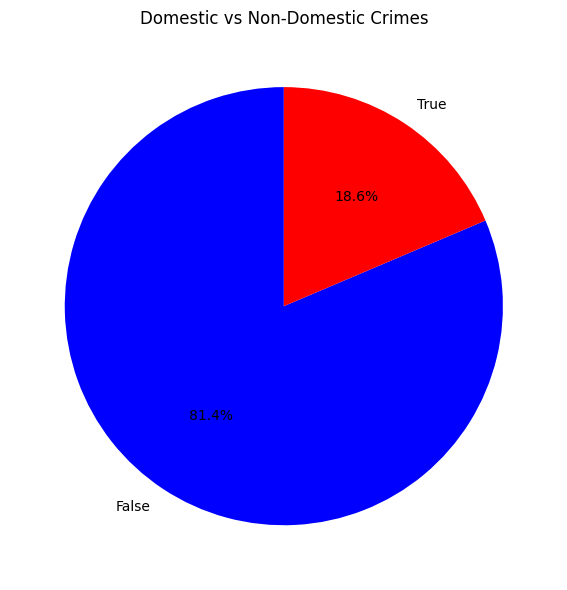

In [10]:
plt.figure(figsize=(6, 6))
domestic_crimes = CC['Domestic'].value_counts()
domestic_crimes.plot(kind='pie', autopct='%1.1f%%', colors=['blue', 'red'], startangle=90)
plt.title('Domestic vs Non-Domestic Crimes')
plt.ylabel('')
plt.tight_layout()
plt.show()


<h1>Insight # 7  Top 10 Locations with the Most Crimes</h1>
<h3>Show the most crime-prone locations.

python
Copy
</h3>

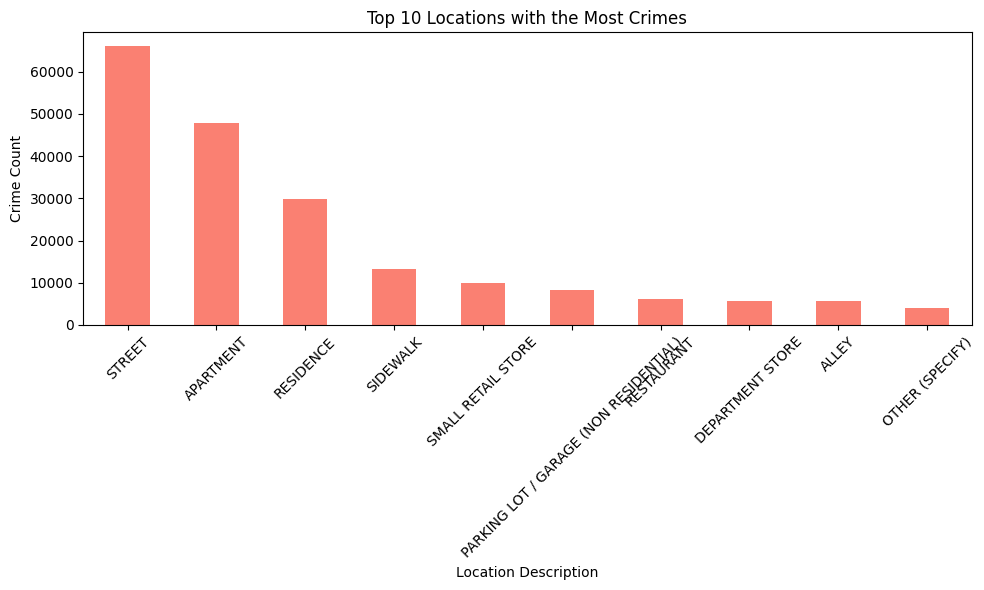

In [11]:
plt.figure(figsize=(10, 6))
top_locations = CC['Location Description'].value_counts().head(10)
top_locations.plot(kind='bar', color='salmon')
plt.title('Top 10 Locations with the Most Crimes')
plt.xlabel('Location Description')
plt.ylabel('Crime Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<h1>Insight # 8 Crimes by FBI Code </h1>
<h3>Display the crime distribution by FBI code.</h3>

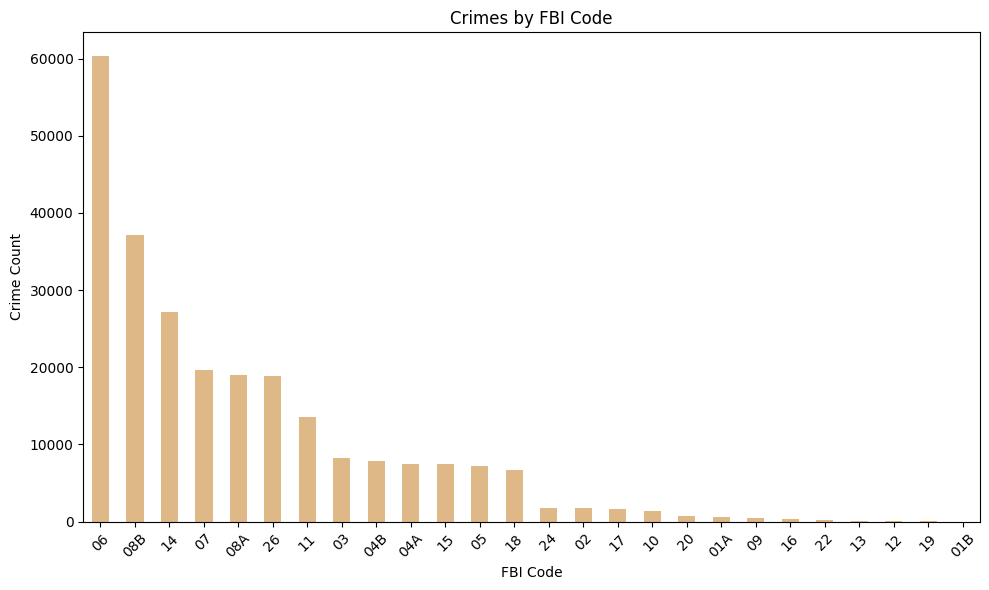

In [12]:
plt.figure(figsize=(10, 6))
fbi_crimes = CC['FBI Code'].value_counts()
fbi_crimes.plot(kind='bar', color='burlywood')
plt.title('Crimes by FBI Code')
plt.xlabel('FBI Code')
plt.ylabel('Crime Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<h1>Insight # 9 chart of Crimes by Ward </h1>
<h3>Show the distribution of crimes by scatterchart.</h3>

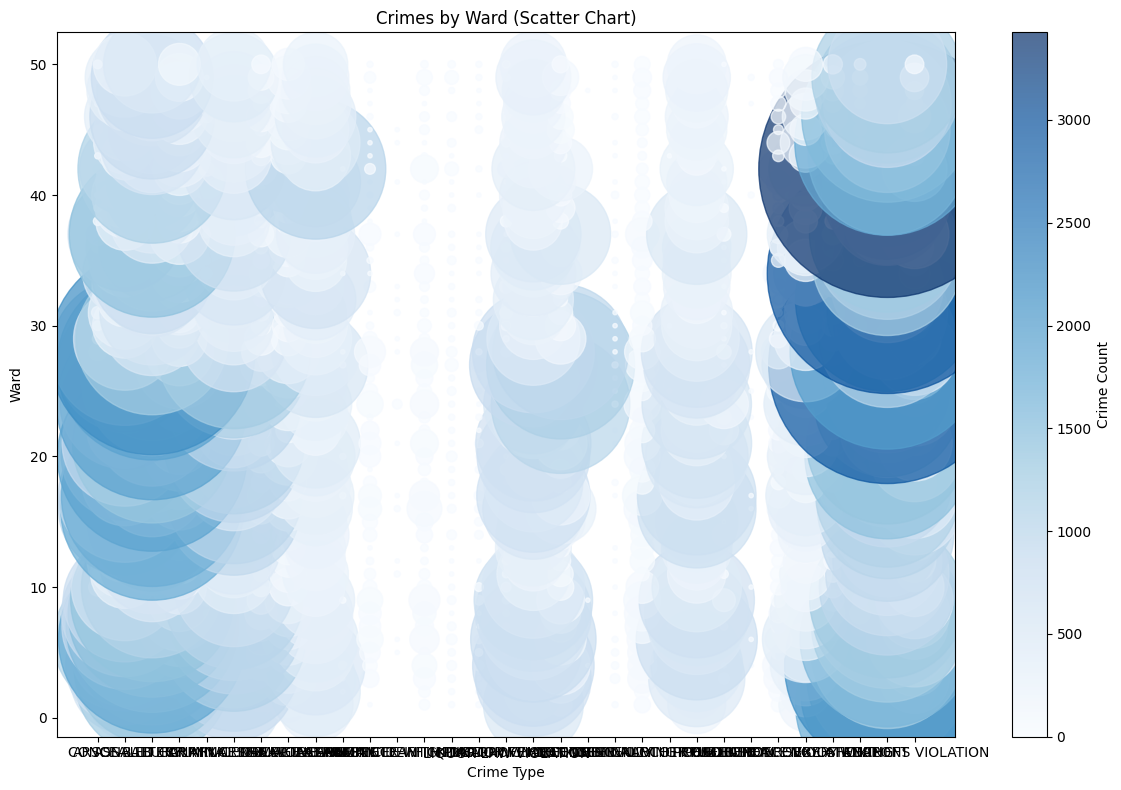

Primary Type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,GAMBLING,...,OTHER NARCOTIC VIOLATION,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
Ward,,,,,,,,,,,,,,,,,,,,,
1,1.0,240.0,484.0,246.0,1.0,440.0,22.0,65.0,291.0,0.0,...,0.0,174.0,0.0,0.0,11.0,148.0,27.0,10.0,1745.0,40.0
2,1.0,253.0,526.0,112.0,2.0,304.0,83.0,134.0,414.0,1.0,...,0.0,146.0,1.0,0.0,19.0,131.0,15.0,7.0,1555.0,84.0
3,3.0,617.0,1237.0,197.0,7.0,795.0,44.0,155.0,334.0,1.0,...,0.0,480.0,6.0,0.0,44.0,154.0,30.0,28.0,1338.0,253.0
4,3.0,730.0,1273.0,219.0,8.0,896.0,46.0,160.0,506.0,4.0,...,0.0,436.0,1.0,1.0,52.0,258.0,47.0,22.0,2187.0,198.0
5,9.0,609.0,1093.0,229.0,2.0,637.0,51.0,92.0,307.0,0.0,...,0.0,381.0,0.0,0.0,11.0,181.0,26.0,13.0,1202.0,190.0
6,31.0,1067.0,1821.0,304.0,6.0,1072.0,53.0,138.0,375.0,0.0,...,0.0,760.0,0.0,1.0,37.0,387.0,35.0,17.0,1578.0,469.0
7,18.0,825.0,1536.0,334.0,1.0,952.0,47.0,113.0,290.0,0.0,...,1.0,482.0,3.0,0.0,10.0,242.0,38.0,19.0,1192.0,227.0
8,26.0,833.0,1461.0,297.0,2.0,941.0,56.0,115.0,287.0,0.0,...,0.0,563.0,0.0,0.0,19.0,261.0,30.0,22.0,1170.0,258.0
9,21.0,791.0,1379.0,204.0,6.0,989.0,41.0,114.0,317.0,2.0,...,0.0,690.0,27.0,0.0,11.0,199.0,25.0,12.0,1251.0,308.0


In [13]:
ward_crimes = CC.groupby('Ward')['Primary Type'].value_counts().unstack().fillna(0)

# Flatten the DataFrame to get individual data points
scatter_data = ward_crimes.stack().reset_index(name='Crime Count')

# Create a scatter plot
plt.figure(figsize=(12, 8))

# Scatter plot: x = Crime Type, y = Ward, size = Crime Count
plt.scatter(data=scatter_data, x='Primary Type', y='Ward', s=scatter_data['Crime Count']*10, c=scatter_data['Crime Count'], cmap='Blues', alpha=0.7)

# Add labels
plt.title('Crimes by Ward (Scatter Chart)')
plt.xlabel('Crime Type')
plt.ylabel('Ward')

# Add a colorbar for the crime count
plt.colorbar(label='Crime Count')

# Adjust layout for a clean fit
plt.tight_layout()

# Show the plot
plt.show()
ward_crimes

<h1>Insight # 10 Crimes by Year and Community Area </h1>
<h3>Show how crimes are distributed across years and community areas.</h3>

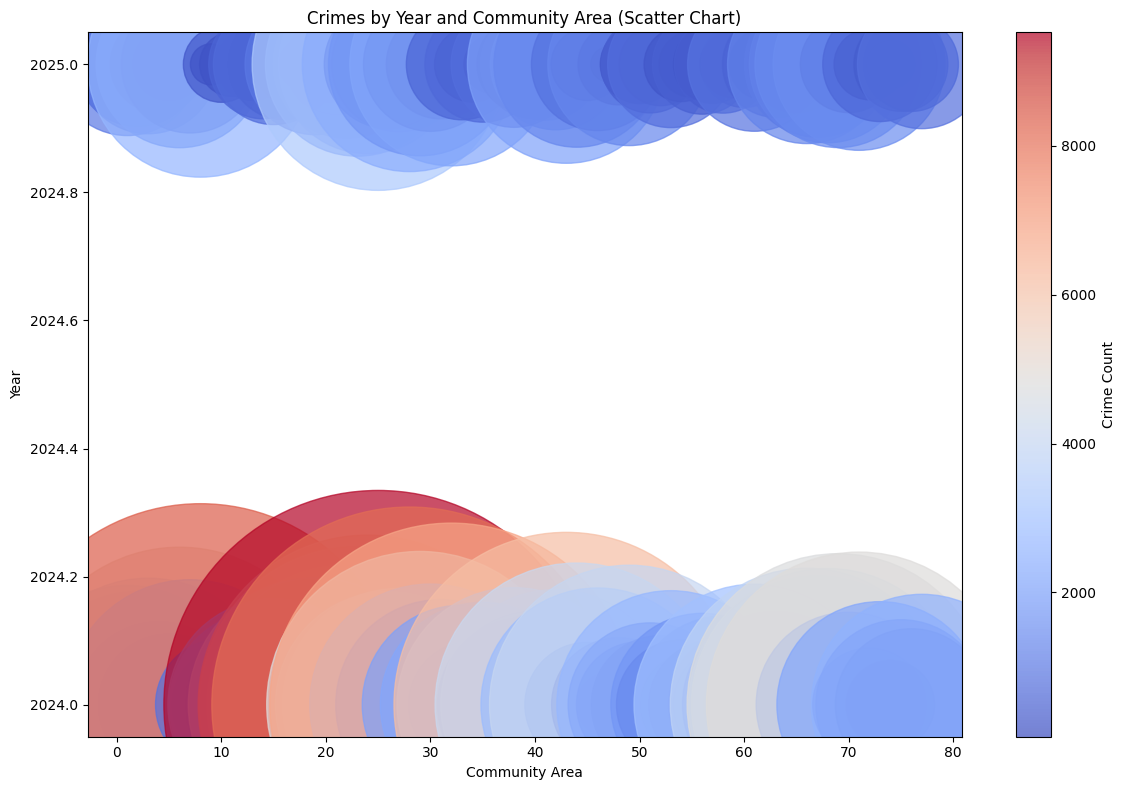

Community Area,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,68.0,69.0,70.0,71.0,72.0,73.0,74.0,75.0,76.0,77.0
Year,,,,,,,,,,,,,,,,,,,,,
2024,2946,2660,3321,1435,1042,5144,3238,8380,193,898,...,3850,4731,1772,4832,668,2203,405,1498,1198,2528
2025,1052,802,999,484,277,1441,977,2639,87,299,...,1275,1436,483,1533,261,679,122,458,460,858


In [14]:
crimes_by_year_community = CC.groupby(['Year', 'Community Area']).size().unstack().fillna(0)

# Flatten the data for scatter plot
scatter_data = crimes_by_year_community.stack().reset_index(name='Crime Count')

# Create a scatter plot
plt.figure(figsize=(12, 8))

# Scatter plot: x = Community Area, y = Year, size = Crime Count
plt.scatter(data=scatter_data, x='Community Area', y='Year', s=scatter_data['Crime Count']*10, c=scatter_data['Crime Count'], cmap='coolwarm', alpha=0.7)

# Add labels
plt.title('Crimes by Year and Community Area (Scatter Chart)')
plt.xlabel('Community Area')
plt.ylabel('Year')

# Add a colorbar for the crime count
plt.colorbar(label='Crime Count')

# Adjust layout for a clean fit
plt.tight_layout()

# Show the plot
plt.show()
crimes_by_year_community

<h1>Insight # 11 Crime Location by Latitude and Longitude</h1>
<h3>Plot crimes based on their latitude and longitude.</h3>

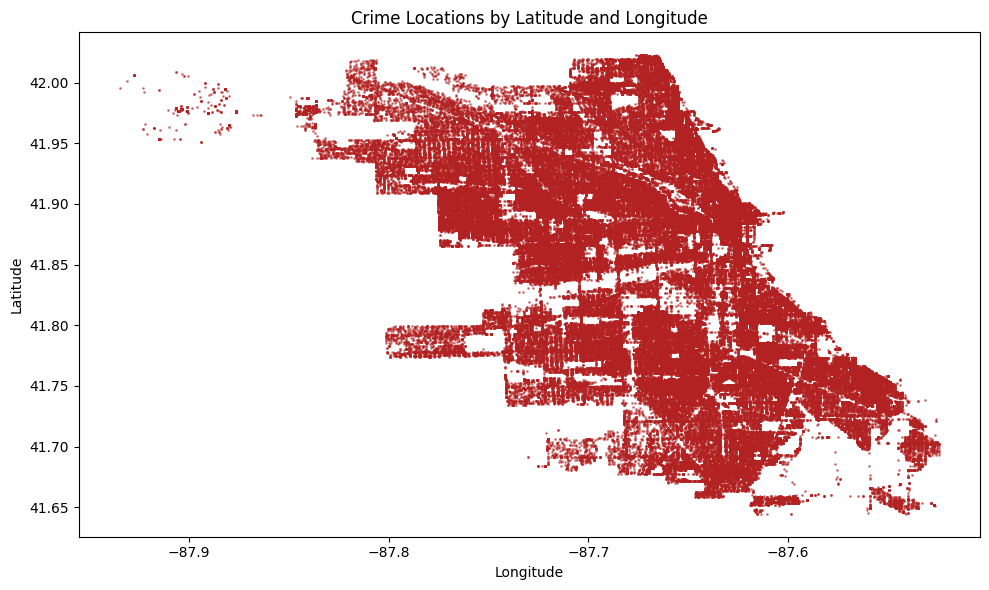

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(CC['Longitude'], CC['Latitude'], c='firebrick', s=1, alpha=0.5)
plt.title('Crime Locations by Latitude and Longitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()


<h1>Insight # 12 Crimes by Block Number</h1>
<h3>Show crimes by block number.</h3>

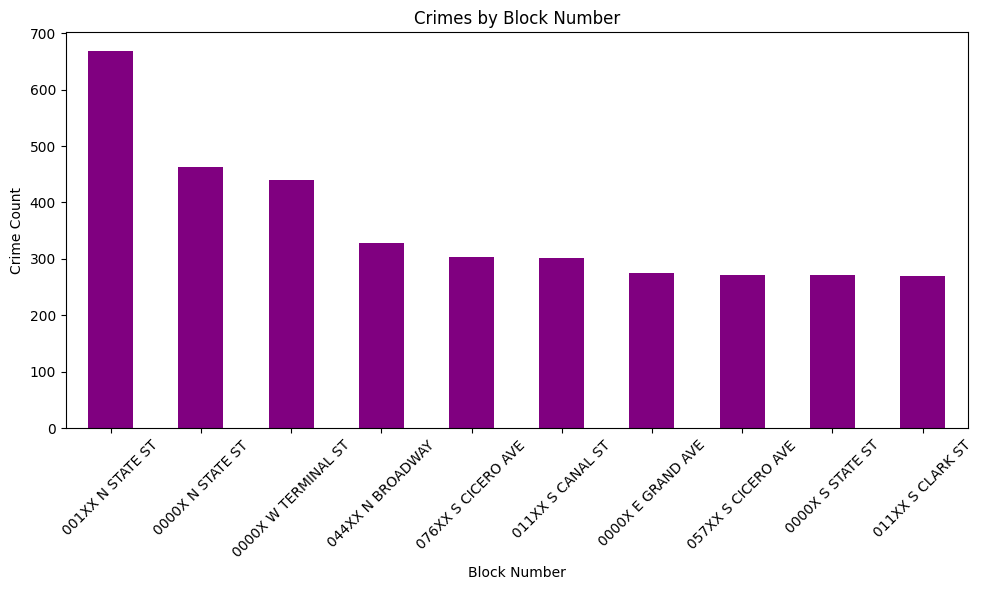

Block
001XX N STATE ST       668
0000X N STATE ST       463
0000X W TERMINAL ST    440
044XX N BROADWAY       328
076XX S CICERO AVE     304
011XX S CANAL ST       301
0000X E GRAND AVE      275
057XX S CICERO AVE     272
0000X S STATE ST       272
011XX S CLARK ST       269
Name: count, dtype: int64

In [16]:
plt.figure(figsize=(10, 6))
block_crimes = CC['Block'].value_counts().head(10)
block_crimes.plot(kind='bar', color='purple')
plt.title('Crimes by Block Number')
plt.xlabel('Block Number')
plt.ylabel('Crime Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
block_crimes

<h1>Insight # 13 Crimes by Year and Crime Type</h1>
<h3>Show crime trends over the years for each crime type.</h3>

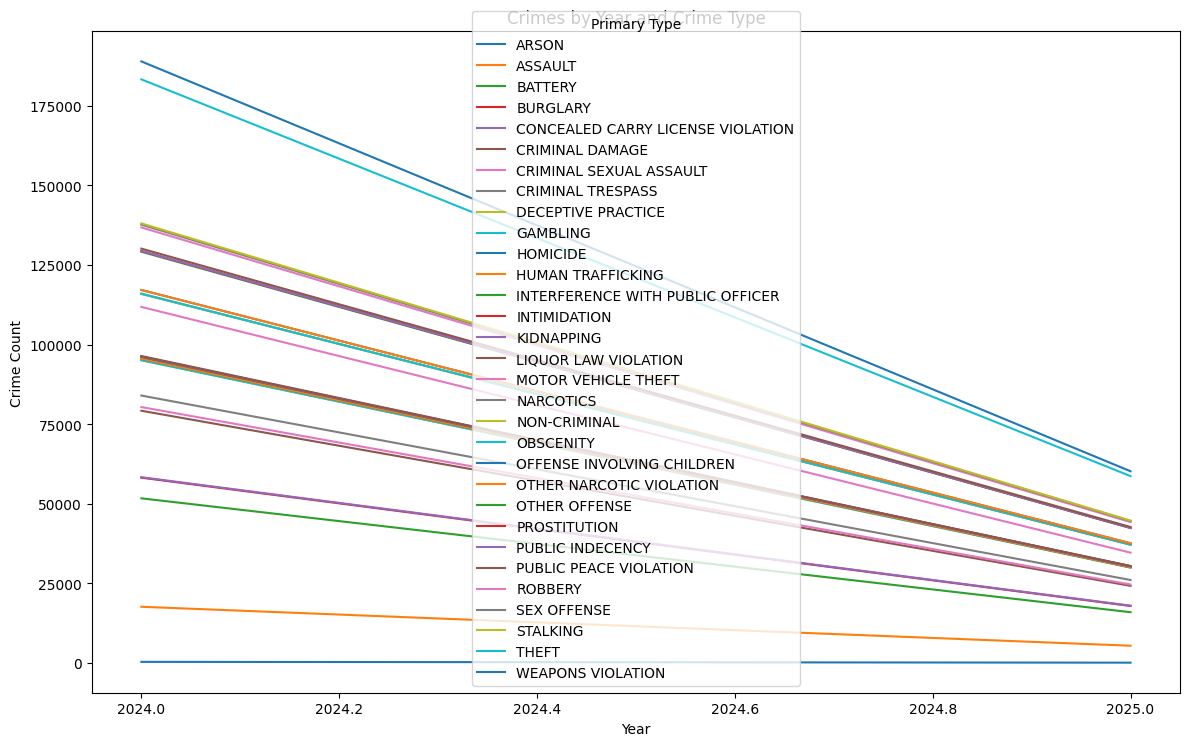

Primary Type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,GAMBLING,...,OTHER NARCOTIC VIOLATION,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
Year,,,,,,,,,,,,,,,,,,,,,
2024,352.0,17298.0,34052.0,6483.0,157.0,20869.0,1155.0,3621.0,11082.0,18.0,...,4.0,12000.0,244.0,8.0,738.0,6647.0,872.0,395.0,45239.0,5638.0
2025,100.0,5317.0,10527.0,1960.0,92.0,6225.0,418.0,1424.0,3909.0,0.0,...,3.0,4781.0,43.0,5.0,268.0,1553.0,338.0,125.0,13962.0,1526.0


In [17]:
crime_by_year_type = CC.groupby(['Year', 'Primary Type']).size().unstack().fillna(0)
crime_by_year_type.plot(kind='line', stacked=True, figsize=(12, 8))
plt.title('Crimes by Year and Crime Type')
plt.xlabel('Year')
plt.ylabel('Crime Count')
plt.tight_layout()
plt.show()
crime_by_year_type

<h1>Insight # 14 Crime Count by Community Area</h1>
<h3>Show crime distribution by community area.</h3>

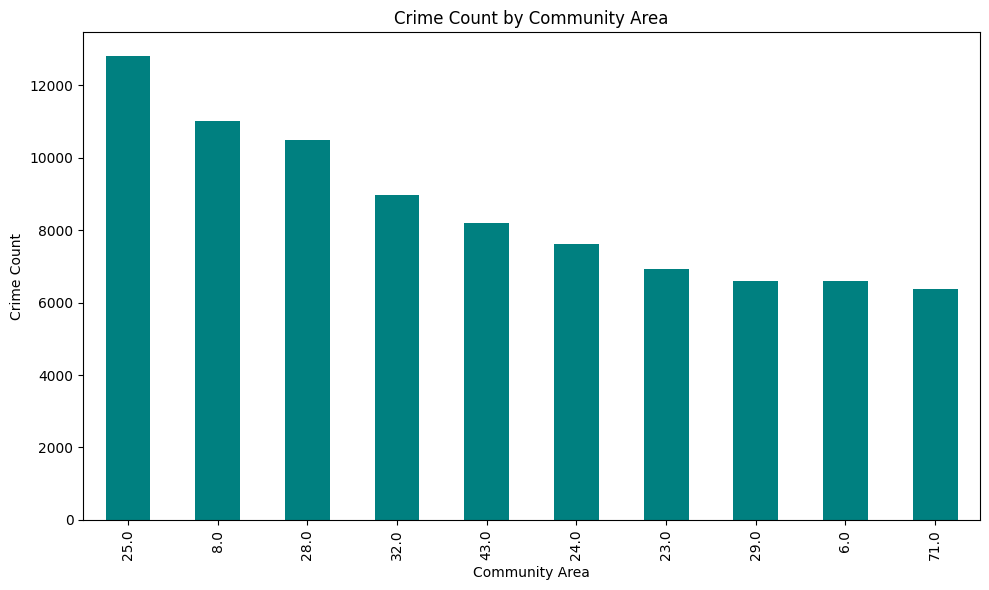

Community Area
25.0    12814
8.0     11019
28.0    10489
32.0     8975
43.0     8190
24.0     7615
23.0     6936
29.0     6605
6.0      6585
71.0     6365
Name: count, dtype: int64

In [18]:
plt.figure(figsize=(10, 6))
community_area_crimes = CC['Community Area'].value_counts().head(10)
community_area_crimes.plot(kind='bar', color='teal')
plt.title('Crime Count by Community Area')
plt.xlabel('Community Area')
plt.ylabel('Crime Count')
plt.tight_layout()
plt.show()
community_area_crimes

<h1>Insight # 15 Crimes by Arrest Status and Crime Type</h1>
<h3>Show arrests by crime type.</h3>

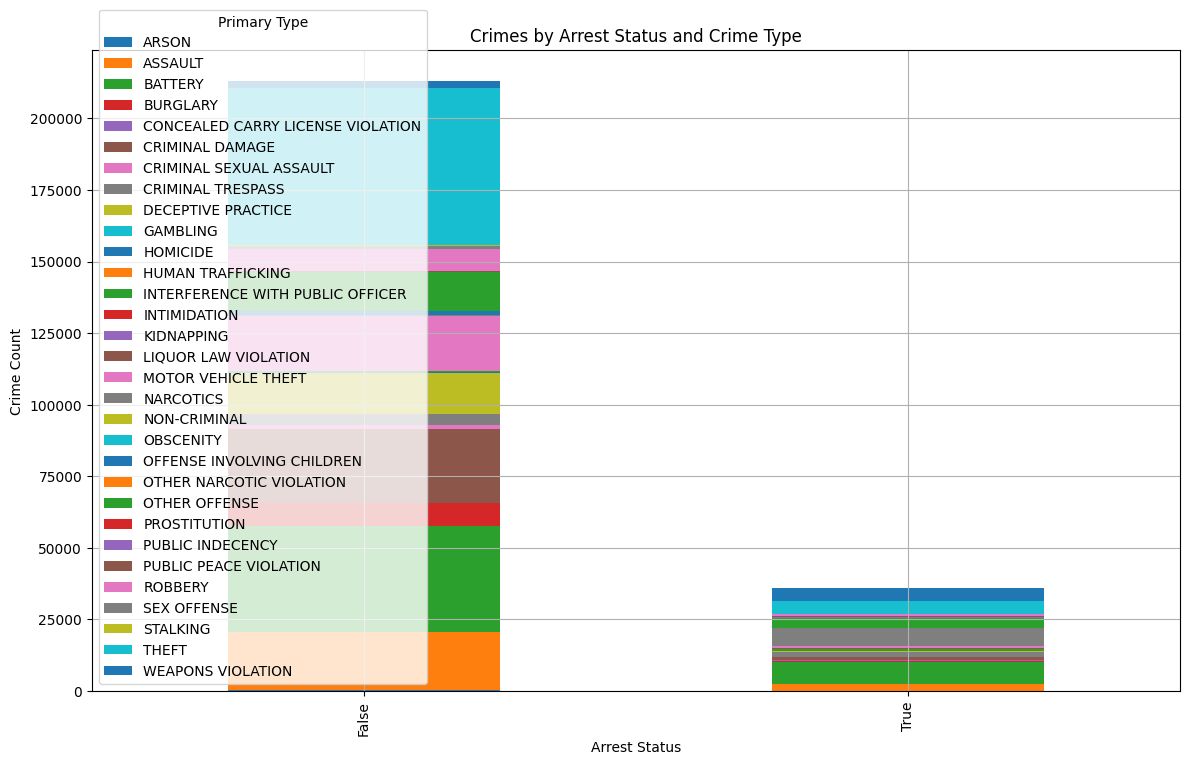

Primary Type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,GAMBLING,...,OTHER NARCOTIC VIOLATION,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
Arrest,,,,,,,,,,,,,,,,,,,,,
False,427.0,20115.0,36932.0,8027.0,3.0,25987.0,1533.0,3569.0,14545.0,0.0,...,5.0,13413.0,14.0,1.0,517.0,7613.0,1123.0,489.0,54672.0,2518.0
True,25.0,2500.0,7647.0,416.0,246.0,1107.0,40.0,1476.0,446.0,18.0,...,2.0,3368.0,273.0,12.0,489.0,587.0,87.0,31.0,4529.0,4646.0


In [19]:
arrest_by_type = CC.groupby(['Arrest', 'Primary Type']).size().unstack().fillna(0)
arrest_by_type.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Crimes by Arrest Status and Crime Type')
plt.xlabel('Arrest Status')
plt.ylabel('Crime Count')
plt.tight_layout()
plt.grid()
plt.show()
arrest_by_type

<h1>Insight # 16 Crime by Time of Day</h1>
<h3>Show the distribution of crimes during different hours of the day.</h3>

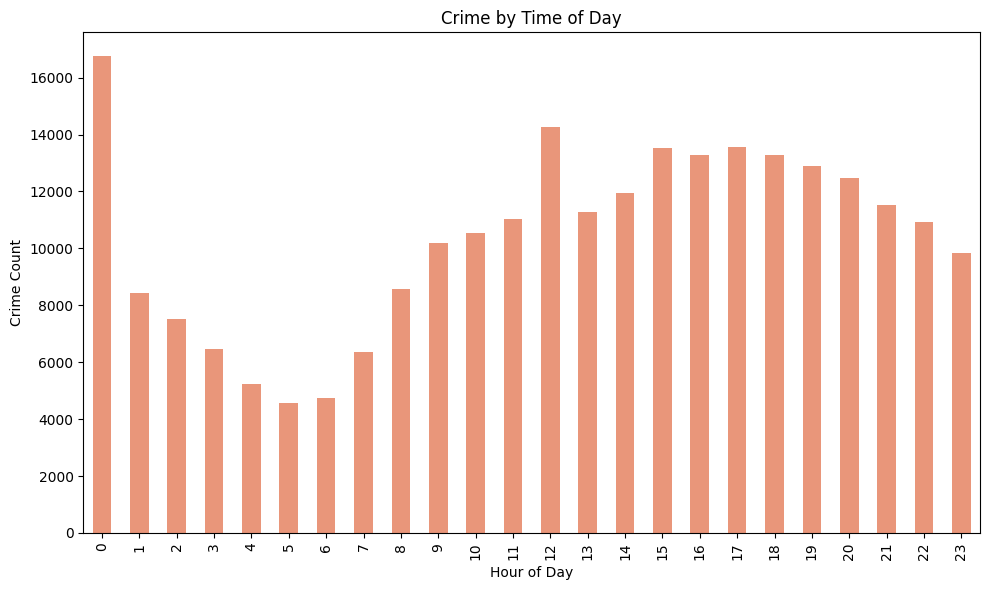

In [20]:
CC['Hour'] = pd.to_datetime(CC['Date']).dt.hour
crime_by_hour = CC.groupby('Hour').size()
crime_by_hour.plot(kind='bar', color='darksalmon', figsize=(10, 6))
plt.title('Crime by Time of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Crime Count')
plt.tight_layout()
plt.show()


<h1>Insight # 17 Crime Location Description by Crime Type</h1>
<h3>Show crimes  for each type of crime.</h3>

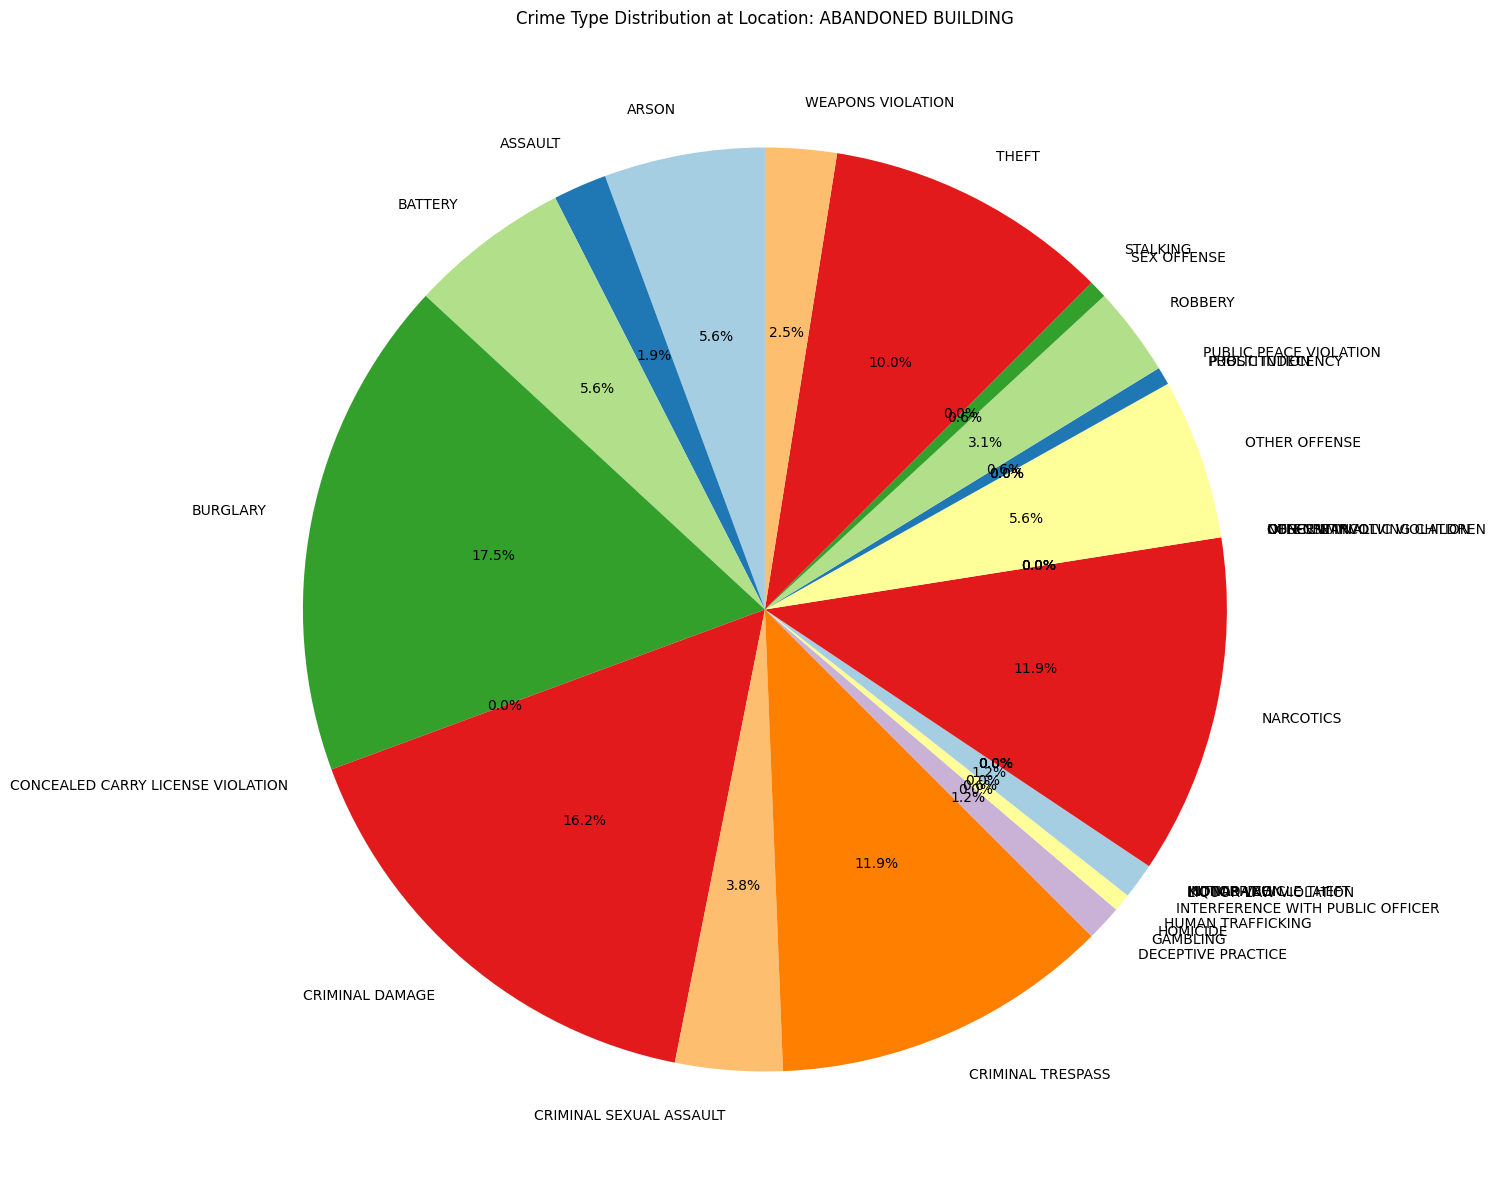

Primary Type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,GAMBLING,...,OTHER NARCOTIC VIOLATION,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
Location Description,,,,,,,,,,,,,,,,,,,,,
ABANDONED BUILDING,9.0,3.0,9.0,28.0,0.0,26.0,6.0,19.0,2.0,0.0,...,0.0,9.0,0.0,0.0,1.0,5.0,1.0,0.0,16.0,4.0
AIRCRAFT,0.0,4.0,14.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,6.0,0.0,0.0,0.0,15.0,0.0
AIRPORT BUILDING NON-TERMINAL - NON-SECURE AREA,0.0,10.0,15.0,0.0,0.0,4.0,1.0,6.0,25.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,1.0
AIRPORT BUILDING NON-TERMINAL - SECURE AREA,0.0,4.0,8.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,...,0.0,5.0,0.0,0.0,1.0,0.0,0.0,1.0,37.0,0.0
AIRPORT EXTERIOR - NON-SECURE AREA,0.0,8.0,13.0,1.0,0.0,11.0,1.0,4.0,16.0,0.0,...,0.0,6.0,0.0,0.0,6.0,1.0,0.0,0.0,29.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VEHICLE - DELIVERY TRUCK,0.0,0.0,1.0,2.0,0.0,3.0,0.0,2.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,33.0,0.0
"VEHICLE - OTHER RIDE SHARE SERVICE (LYFT, UBER, ETC.)",0.0,8.0,34.0,0.0,0.0,2.0,0.0,0.0,13.0,0.0,...,0.0,2.0,0.0,0.0,0.0,8.0,7.0,0.0,34.0,4.0
VEHICLE NON-COMMERCIAL,19.0,102.0,403.0,96.0,3.0,513.0,26.0,38.0,36.0,0.0,...,0.0,154.0,0.0,0.0,10.0,73.0,13.0,2.0,1273.0,149.0


In [21]:
# Assuming 'CC' is your DataFrame with 'Location Description' and 'Primary Type' columns
# Group the data by Location Description and Primary Type to count the number of crimes
location_crimes = CC.groupby(['Location Description', 'Primary Type']).size().unstack().fillna(0)

# Select a specific location to plot the pie chart for that location's crime types
# For example, let's look at crimes for the first location in the dataset
location = location_crimes.iloc[0]  # Change this to any location you want to analyze

# Create a pie plot
plt.figure(figsize=(15, 15))
plt.pie(location, labels=location.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# Set the title
plt.title(f'Crime Type Distribution at Location: {location_crimes.index[0]}')

# Show the plot
plt.show()
location_crimes

<h1>Insight # 18 Crimes by Domestic Crime Type</h1>
<h3>Display the most common domestic crimes.</h3>

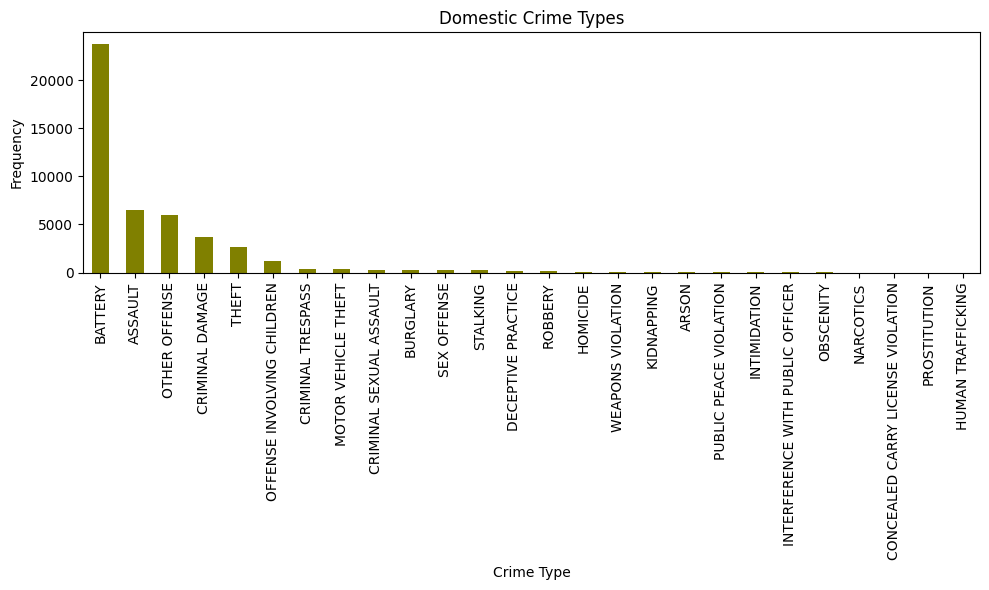

Primary Type
BATTERY                              23764
ASSAULT                               6453
OTHER OFFENSE                         5970
CRIMINAL DAMAGE                       3736
THEFT                                 2674
OFFENSE INVOLVING CHILDREN            1219
CRIMINAL TRESPASS                      375
MOTOR VEHICLE THEFT                    351
CRIMINAL SEXUAL ASSAULT                309
BURGLARY                               305
SEX OFFENSE                            257
STALKING                               248
DECEPTIVE PRACTICE                     216
ROBBERY                                209
HOMICIDE                                48
WEAPONS VIOLATION                       46
KIDNAPPING                              39
ARSON                                   38
PUBLIC PEACE VIOLATION                  34
INTIMIDATION                            24
INTERFERENCE WITH PUBLIC OFFICER        12
OBSCENITY                               11
NARCOTICS                                

In [22]:
domestic_crimes = CC[CC['Domestic'] == True]['Primary Type'].value_counts()
domestic_crimes.plot(kind='bar', color='olive', figsize=(10, 6))
plt.title('Domestic Crime Types')
plt.xlabel('Crime Type')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
domestic_crimes

<h1>Insight # 19  Top 5 Crime Blocks</h1>
<h3>Show the blocks with the most crimes.</h3>

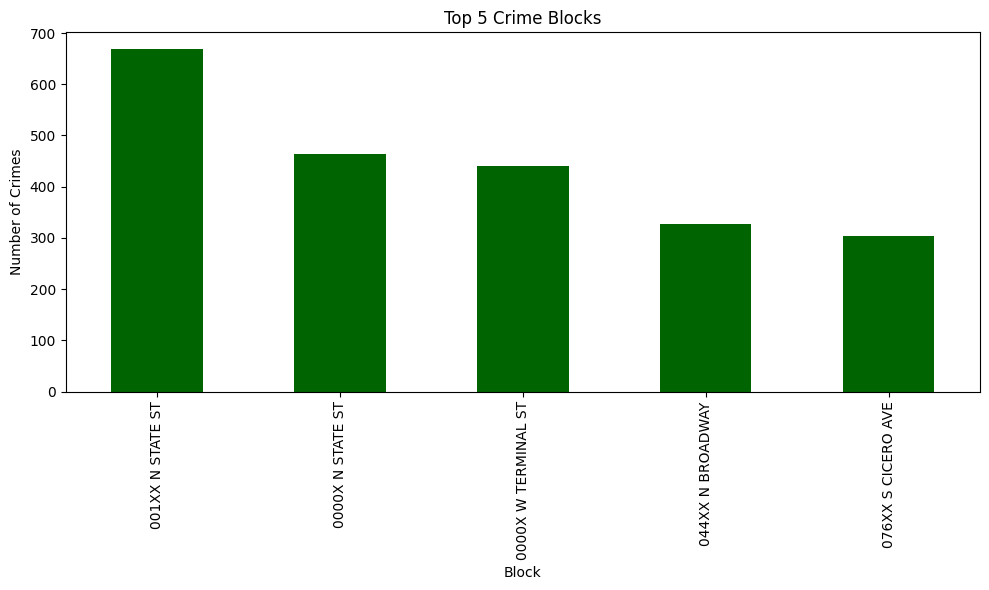

Block
001XX N STATE ST       668
0000X N STATE ST       463
0000X W TERMINAL ST    440
044XX N BROADWAY       328
076XX S CICERO AVE     304
Name: count, dtype: int64

In [23]:
block_crimes = CC['Block'].value_counts().head(5)
block_crimes.plot(kind='bar', color='darkgreen', figsize=(10, 6))
plt.title('Top 5 Crime Blocks')
plt.xlabel('Block')
plt.ylabel('Number of Crimes')
plt.tight_layout()
plt.show()
block_crimes

<h1>Insight # 20 Crimes by Latitude and Longitude</h1>
<h3>Show crimes' geographical distribution with a density heatmap.</h3>

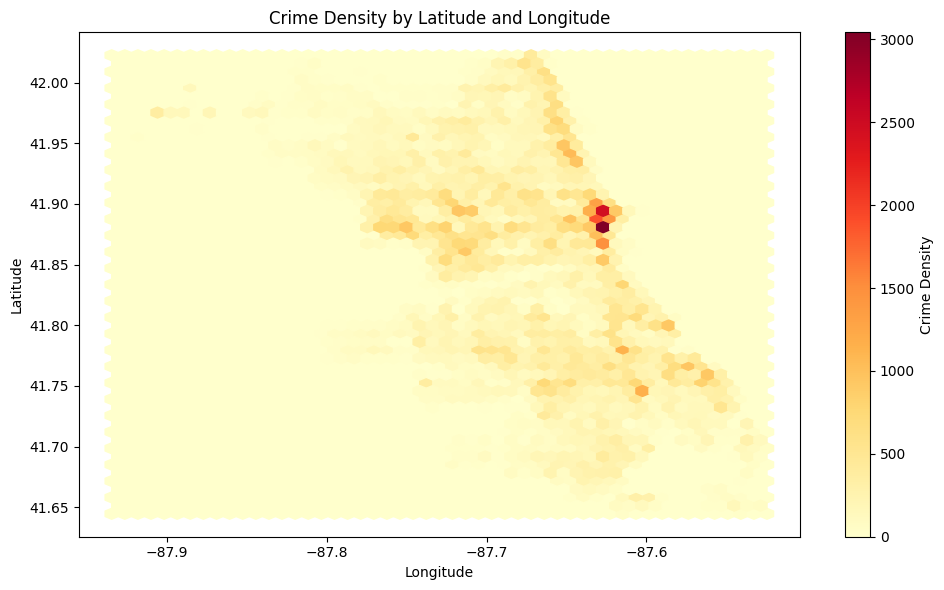

In [24]:
plt.figure(figsize=(10, 6))
plt.hexbin(CC['Longitude'], CC['Latitude'], gridsize=50, cmap='YlOrRd')
plt.colorbar(label='Crime Density')
plt.title('Crime Density by Latitude and Longitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()


<h1>Insight # 21 Top 5 Domestic Crime Locations</h1>
<h3>Display the top locations for domestic crimes.</h3>

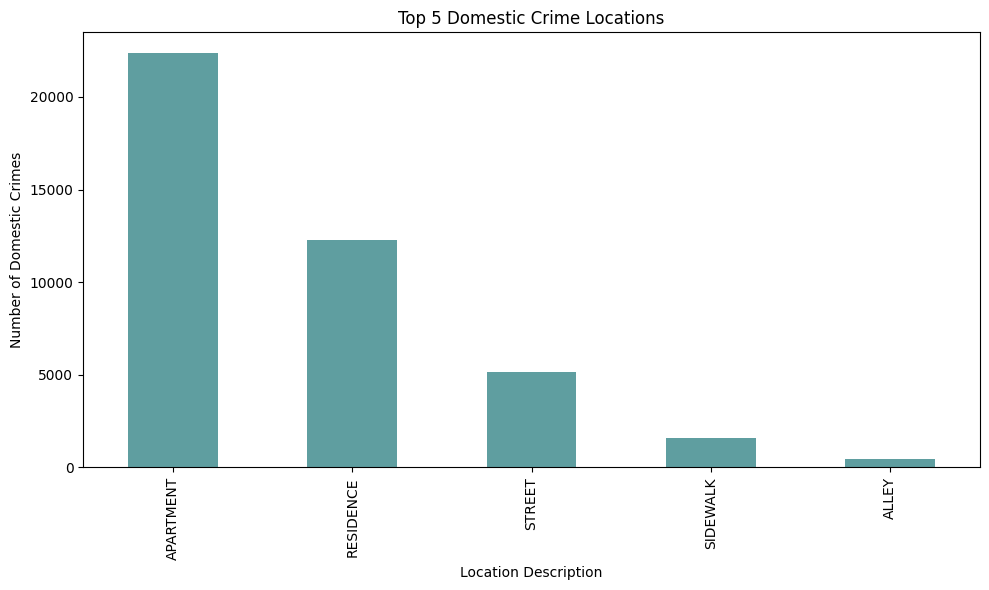

Location Description
APARTMENT    22370
RESIDENCE    12275
STREET        5162
SIDEWALK      1612
ALLEY          483
Name: count, dtype: int64

In [25]:
domestic_location_crimes = CC[CC['Domestic'] == True]['Location Description'].value_counts().head(5)
domestic_location_crimes.plot(kind='bar', color='cadetblue', figsize=(10, 6))
plt.title('Top 5 Domestic Crime Locations')
plt.xlabel('Location Description')
plt.ylabel('Number of Domestic Crimes')
plt.tight_layout()
plt.show()
domestic_location_crimes

<h1>Insight # 22 Top 10 Crime Locations</h1>
<h3>This visualization will show the top 10 locations with the highest crime frequency. It will use a horizontal bar chart to display the crime count for each location, making it easy to compare locations at a glance.</h3>

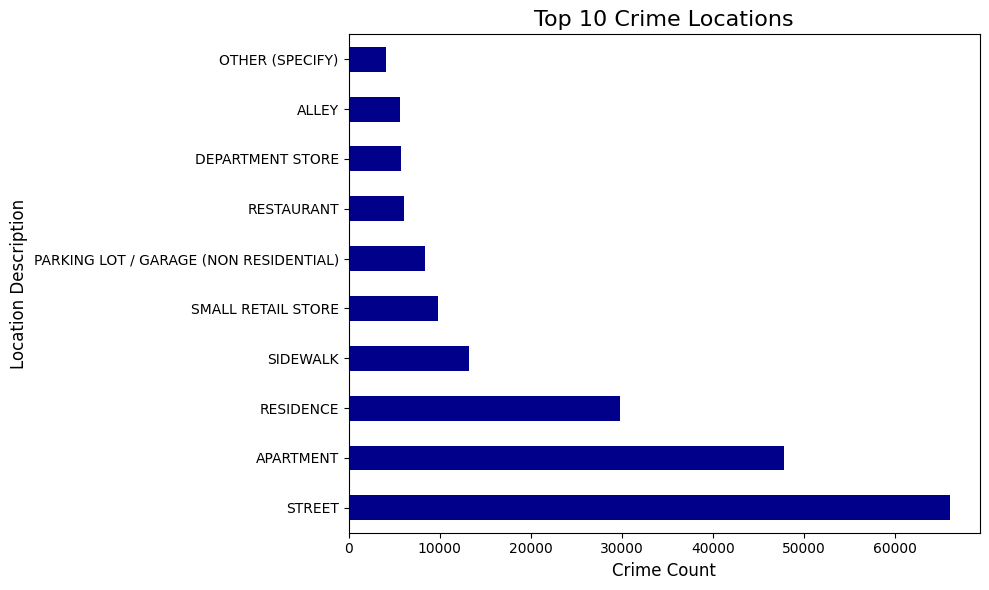

In [26]:
# Group the data by 'Location Description' to count the number of crimes
crime_by_location = CC.groupby('Location Description').size().sort_values(ascending=False).head(10)

# Create a horizontal bar chart for the top 10 crime locations
plt.figure(figsize=(10, 6))
crime_by_location.plot(kind='barh', color='darkblue')

# Set the title and labels
plt.title('Top 10 Crime Locations', fontsize=16)
plt.xlabel('Crime Count', fontsize=12)
plt.ylabel('Location Description', fontsize=12)

# Adjust layout for a clean fit
plt.tight_layout()

# Show the plot
plt.show()


<h1>Insight # 23 Crimes by FBI Code</h1>
<h3>Show crimes distributed by FBI Code.</h3>

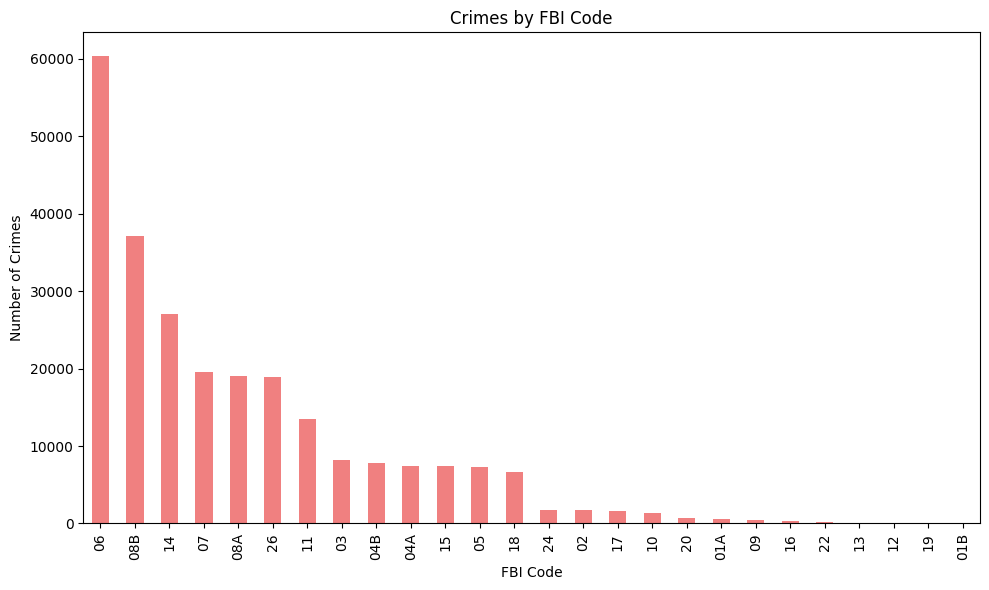

FBI Code
06     60380
08B    37090
14     27094
07     19604
08A    19009
26     18855
11     13534
03      8200
04B     7851
04A     7473
15      7417
05      7264
18      6617
24      1759
02      1751
17      1578
10      1360
20       696
01A      551
09       452
16       287
22       192
13        63
12        26
19        18
01B        2
Name: count, dtype: int64

In [27]:
fbi_crimes = CC['FBI Code'].value_counts()
fbi_crimes.plot(kind='bar', color='lightcoral', figsize=(10, 6))
plt.title('Crimes by FBI Code')
plt.xlabel('FBI Code')
plt.ylabel('Number of Crimes')
plt.tight_layout()
plt.show()
fbi_crimes

<h1>Insight # 24 Crime Heatmap by Community Area</h1>
<h3>Show the distribution of crimes across community areas.</h3>

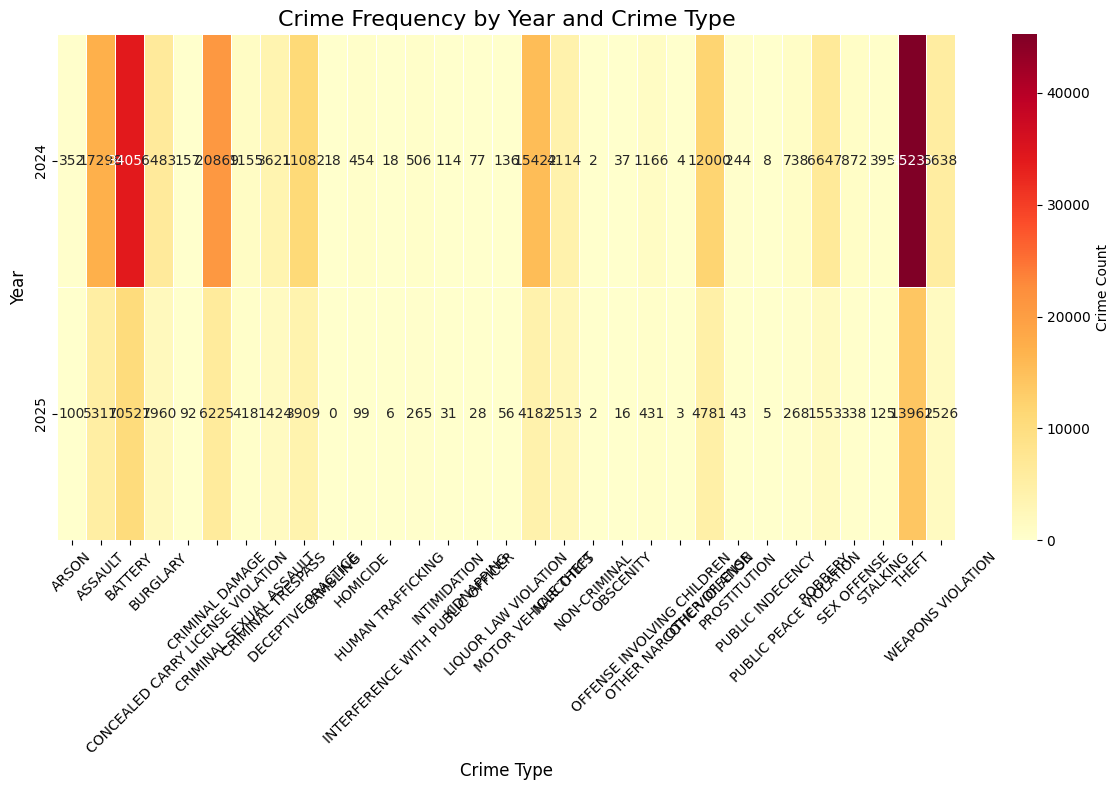

Primary Type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,GAMBLING,...,OTHER NARCOTIC VIOLATION,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
Year,,,,,,,,,,,,,,,,,,,,,
2024,352.0,17298.0,34052.0,6483.0,157.0,20869.0,1155.0,3621.0,11082.0,18.0,...,4.0,12000.0,244.0,8.0,738.0,6647.0,872.0,395.0,45239.0,5638.0
2025,100.0,5317.0,10527.0,1960.0,92.0,6225.0,418.0,1424.0,3909.0,0.0,...,3.0,4781.0,43.0,5.0,268.0,1553.0,338.0,125.0,13962.0,1526.0


In [28]:
crime_by_year = CC.groupby(['Year', 'Primary Type']).size().unstack().fillna(0)

# Create the heatmap
plt.figure(figsize=(12, 8))

# Create a heatmap with annotations, color map, and color bar
sns.heatmap(crime_by_year, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.5, cbar_kws={'label': 'Crime Count'}, annot_kws={'size': 10})

# Set the title and labels
plt.title('Crime Frequency by Year and Crime Type', fontsize=16)
plt.xlabel('Crime Type', fontsize=12)
plt.ylabel('Year', fontsize=12)

# Rotate the labels on x-axis for readability
plt.xticks(rotation=45)

# Adjust layout for a clean fit
plt.tight_layout()

# Show the plot
plt.show()
crime_by_year

<h1>Insight # 25 Top 5 Crime Time Trends</h1>
<h3>Show the trend of top crimes by hour of the day.</h3>

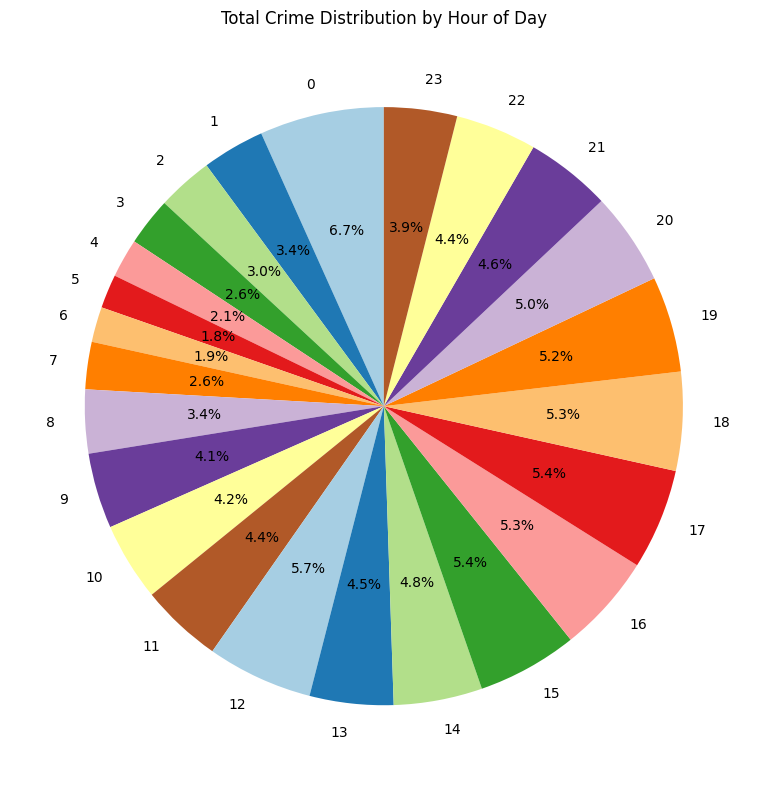

In [29]:
# Group the data by Hour and Primary Type to count the number of crimes
crime_by_hour_type = CC.groupby(['Hour', 'Primary Type']).size().unstack().fillna(0)

# Sum all crime types for each hour to get total crime counts per hour
total_crimes_by_hour = crime_by_hour_type.sum(axis=1)

# Create the pie chart
plt.figure(figsize=(8, 8))
total_crimes_by_hour.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors, legend=False)

# Set the title and labels
plt.title('Total Crime Distribution by Hour of Day')

# Show the plot
plt.tight_layout()
plt.show()


<h1>Insight # 26 Crime Trend by Ward</h1>
<h3>Show the trends in crime types per ward.</h3>

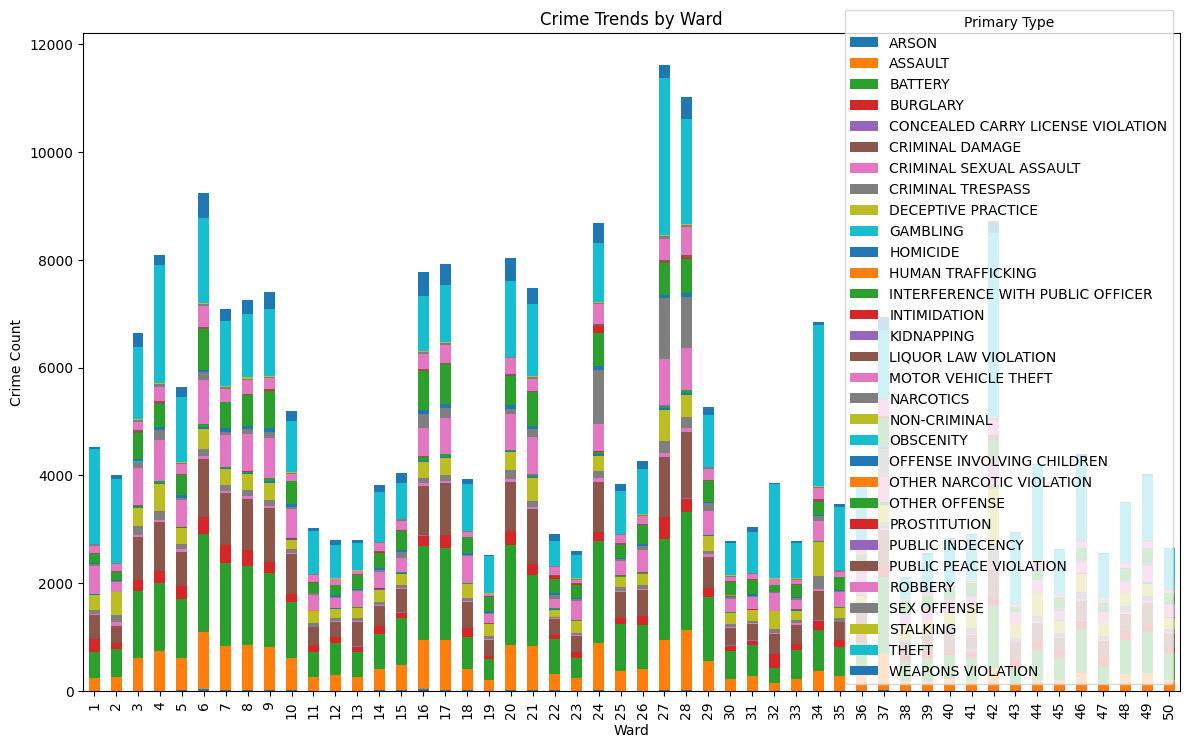

Primary Type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,GAMBLING,...,OTHER NARCOTIC VIOLATION,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
Ward,,,,,,,,,,,,,,,,,,,,,
1,1.0,240.0,484.0,246.0,1.0,440.0,22.0,65.0,291.0,0.0,...,0.0,174.0,0.0,0.0,11.0,148.0,27.0,10.0,1745.0,40.0
2,1.0,253.0,526.0,112.0,2.0,304.0,83.0,134.0,414.0,1.0,...,0.0,146.0,1.0,0.0,19.0,131.0,15.0,7.0,1555.0,84.0
3,3.0,617.0,1237.0,197.0,7.0,795.0,44.0,155.0,334.0,1.0,...,0.0,480.0,6.0,0.0,44.0,154.0,30.0,28.0,1338.0,253.0
4,3.0,730.0,1273.0,219.0,8.0,896.0,46.0,160.0,506.0,4.0,...,0.0,436.0,1.0,1.0,52.0,258.0,47.0,22.0,2187.0,198.0
5,9.0,609.0,1093.0,229.0,2.0,637.0,51.0,92.0,307.0,0.0,...,0.0,381.0,0.0,0.0,11.0,181.0,26.0,13.0,1202.0,190.0
6,31.0,1067.0,1821.0,304.0,6.0,1072.0,53.0,138.0,375.0,0.0,...,0.0,760.0,0.0,1.0,37.0,387.0,35.0,17.0,1578.0,469.0
7,18.0,825.0,1536.0,334.0,1.0,952.0,47.0,113.0,290.0,0.0,...,1.0,482.0,3.0,0.0,10.0,242.0,38.0,19.0,1192.0,227.0
8,26.0,833.0,1461.0,297.0,2.0,941.0,56.0,115.0,287.0,0.0,...,0.0,563.0,0.0,0.0,19.0,261.0,30.0,22.0,1170.0,258.0
9,21.0,791.0,1379.0,204.0,6.0,989.0,41.0,114.0,317.0,2.0,...,0.0,690.0,27.0,0.0,11.0,199.0,25.0,12.0,1251.0,308.0


In [30]:
crime_by_ward = CC.groupby(['Ward', 'Primary Type']).size().unstack().fillna(0)
crime_by_ward.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Crime Trends by Ward')
plt.xlabel('Ward')
plt.ylabel('Crime Count')
plt.tight_layout()
plt.show()
crime_by_ward

<h1>Insight # 27 Top 5 Crime Areas</h1>
<h3>Show top crime areas with the highest number of crimes.</h3>

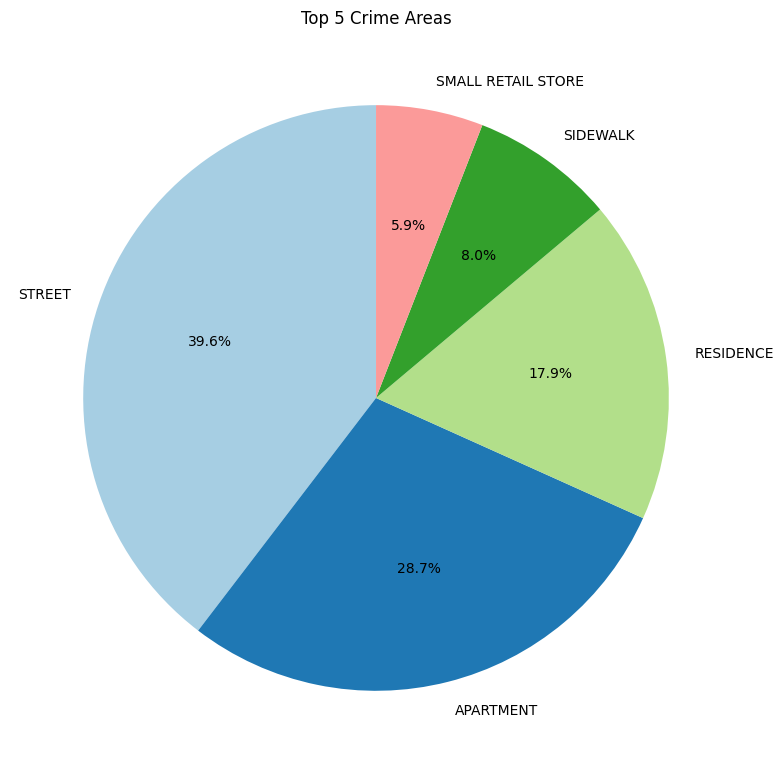

In [31]:
crime_area = CC.groupby('Location Description').size().sort_values(ascending=False).head(5)

# Create a pie chart
plt.figure(figsize=(8, 8))
crime_area.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors, legend=False)

# Set the title
plt.title('Top 5 Crime Areas')

# Show the plot
plt.tight_layout()
plt.show()

<h1>Insight # 28 Crime Correlation with Year</h1>
<h3>Show the relationship between the year and crime count.</h3>

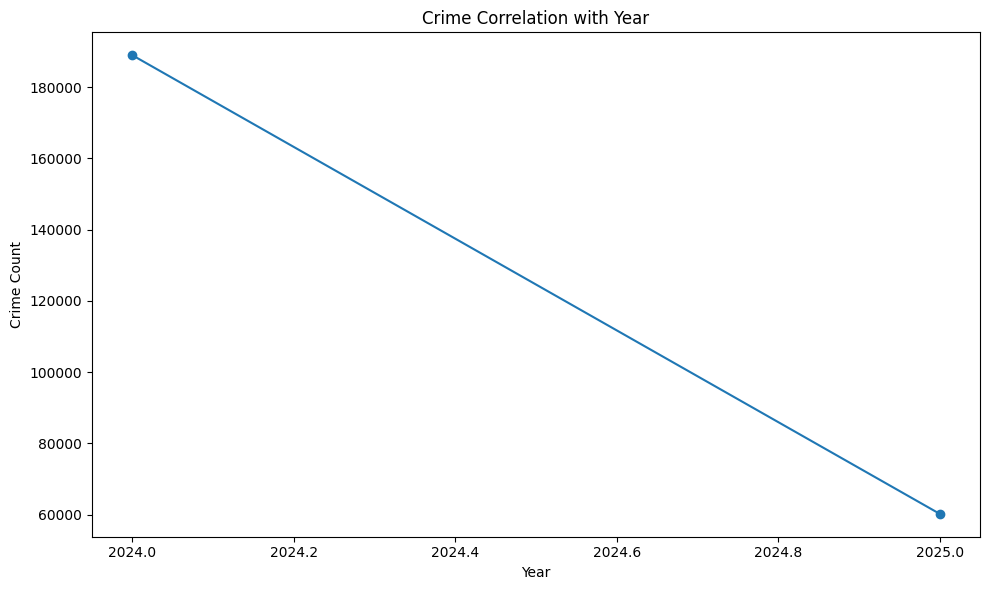

In [32]:
crime_by_year = CC.groupby('Year').size()
crime_by_year.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Crime Correlation with Year')
plt.xlabel('Year')
plt.ylabel('Crime Count')
plt.tight_layout()
plt.show()


<h1>Insight # 29 Crime Frequency by Location Type</h1>
<h3>Show crime frequency by location type (apartment, street, etc.).</h3>

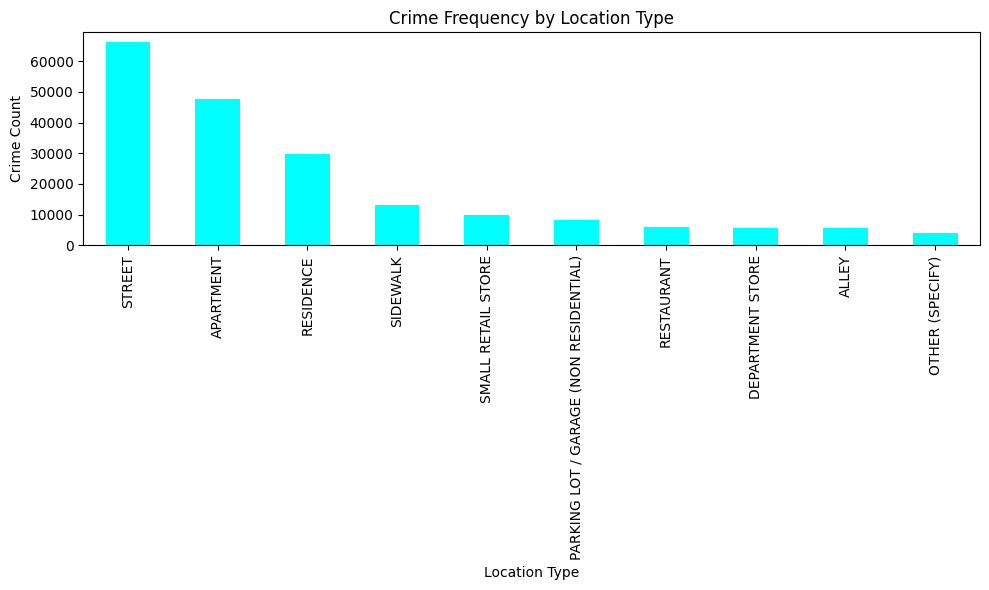

Location Description
STREET                                    66040
APARTMENT                                 47787
RESIDENCE                                 29776
SIDEWALK                                  13265
SMALL RETAIL STORE                         9858
PARKING LOT / GARAGE (NON RESIDENTIAL)     8350
RESTAURANT                                 6094
DEPARTMENT STORE                           5768
ALLEY                                      5695
OTHER (SPECIFY)                            4072
Name: count, dtype: int64

In [33]:
crime_by_location = CC['Location Description'].value_counts().head(10)
crime_by_location.plot(kind='bar', color='cyan', figsize=(10, 6))
plt.title('Crime Frequency by Location Type')
plt.xlabel('Location Type')
plt.ylabel('Crime Count')
plt.tight_layout()
plt.show()
crime_by_location

<h1>Insight # 30 Time of Day Crime Distribution</h1>
<h3>Show crimes throughout the day.</h3>

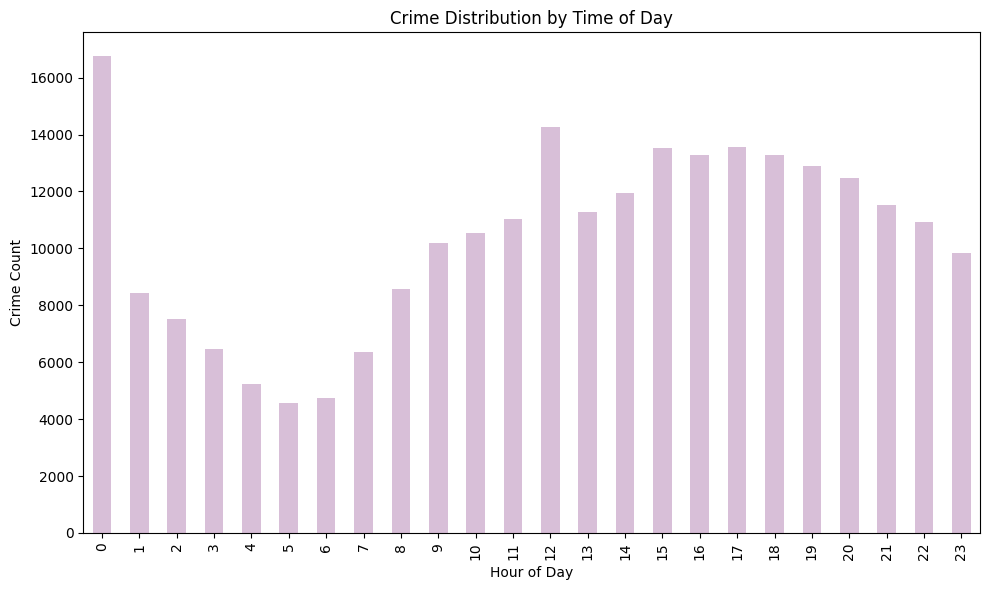

Hour
0     16752
1      8420
2      7504
3      6477
4      5227
5      4551
6      4744
7      6368
8      8576
9     10171
10    10543
11    11023
12    14247
13    11268
14    11936
15    13511
16    13288
17    13566
18    13286
19    12902
20    12460
21    11534
22    10936
23     9833
dtype: int64

In [34]:
CC['Hour'] = pd.to_datetime(CC['Date']).dt.hour
crime_by_time_of_day = CC.groupby('Hour').size()
crime_by_time_of_day.plot(kind='bar', color='thistle', figsize=(10, 6))
plt.title('Crime Distribution by Time of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Crime Count')
plt.tight_layout()
plt.show()
crime_by_time_of_day

<h1>Insight 31 Crime Severity by Location</h1>
<h3>Show severity (e.g., violent crimes) by location.</h3>

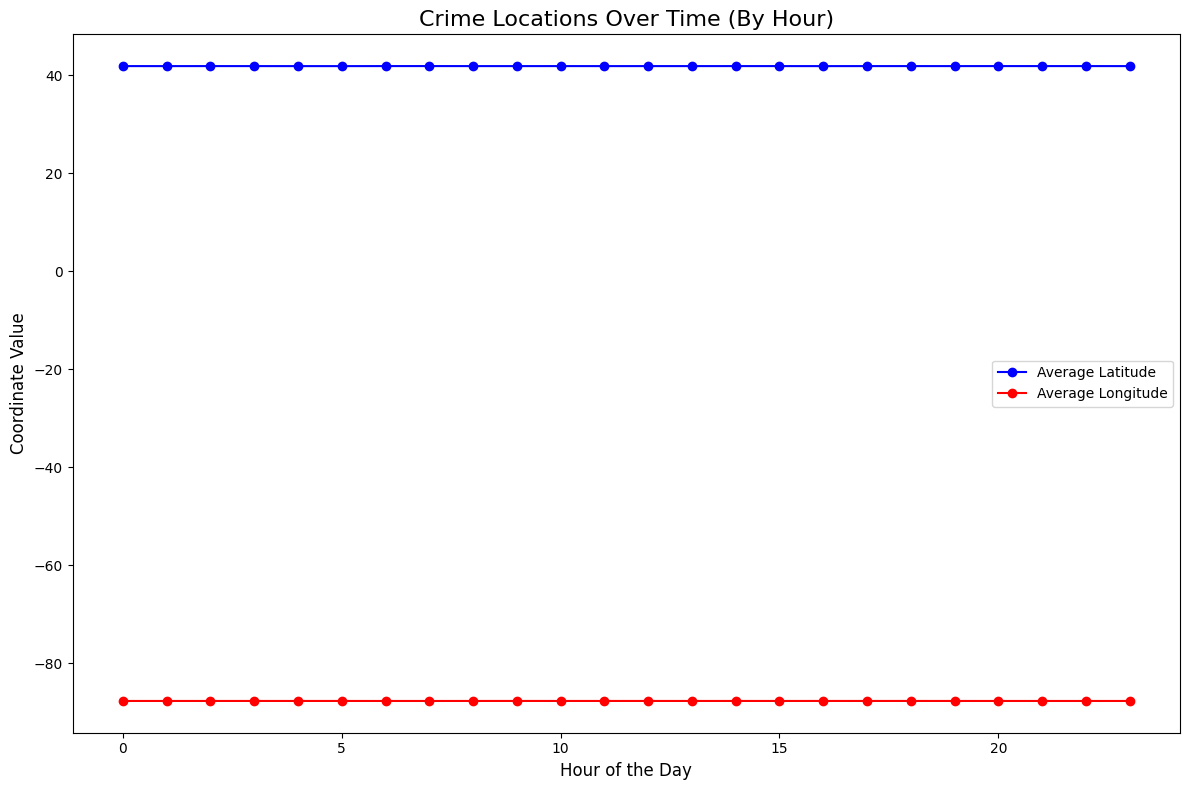

In [35]:


# Filter violent crimes
violent_crimes = CC[CC['Primary Type'].isin(['ASSAULT', 'BATTERY', 'WEAPONS VIOLATION'])]

# Group the data by Hour and calculate the average latitude and longitude for each hour
crime_by_hour = violent_crimes.groupby('Hour').agg({'Latitude': 'mean', 'Longitude': 'mean'}).reset_index()

# Create the line plot
plt.figure(figsize=(12, 8))

# Plot Latitude and Longitude as two separate lines over the hours of the day
plt.plot(crime_by_hour['Hour'], crime_by_hour['Latitude'], label='Average Latitude', color='blue', marker='o')
plt.plot(crime_by_hour['Hour'], crime_by_hour['Longitude'], label='Average Longitude', color='red', marker='o')

# Set the title and labels
plt.title('Crime Locations Over Time (By Hour)', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Coordinate Value', fontsize=12)

# Add a legend
plt.legend()

# Adjust layout for a clean fit
plt.tight_layout()

# Show the plot
plt.show()
